In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from tqdm import tqdm

In [2]:
BASE_DIR = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"

TRAIN_DIR = os.path.join(BASE_DIR, "genres_stems")
TEST_DIR = os.path.join(BASE_DIR, "mashups")
TEST_CSV = os.path.join(BASE_DIR, "test.csv")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
genres = sorted(os.listdir(TRAIN_DIR))

data = []
for g in genres:
    data.append([g, len(os.listdir(os.path.join(TRAIN_DIR, g)))])

df = pd.DataFrame(data, columns=["genre", "count"])
df

,genre,count
0,blues,100
1,classical,100
2,country,100
3,disco,100
4,hiphop,100
5,jazz,100
6,metal,100
7,pop,100
8,reggae,100
9,rock,100


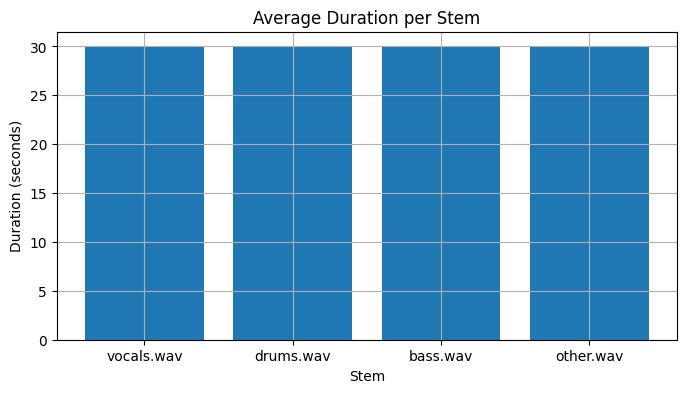

In [4]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt

stems = ["vocals.wav", "drums.wav", "bass.wav", "other.wav"]

avg_durations = []

for stem in stems:
    durations = []
    
    for g in genres:
        sample = os.listdir(os.path.join(TRAIN_DIR, g))[0]  
        path = os.path.join(TRAIN_DIR, g, sample, stem)
        
        if os.path.exists(path):
            duration = librosa.get_duration(path=path)
            durations.append(duration)
    
    avg_durations.append(np.mean(durations))

x = np.arange(len(stems))

plt.figure(figsize=(8,4))
plt.bar(x, avg_durations)

plt.xticks(x, stems)
plt.title("Average Duration per Stem")
plt.xlabel("Stem")
plt.ylabel("Duration (seconds)")
plt.grid()

plt.show()

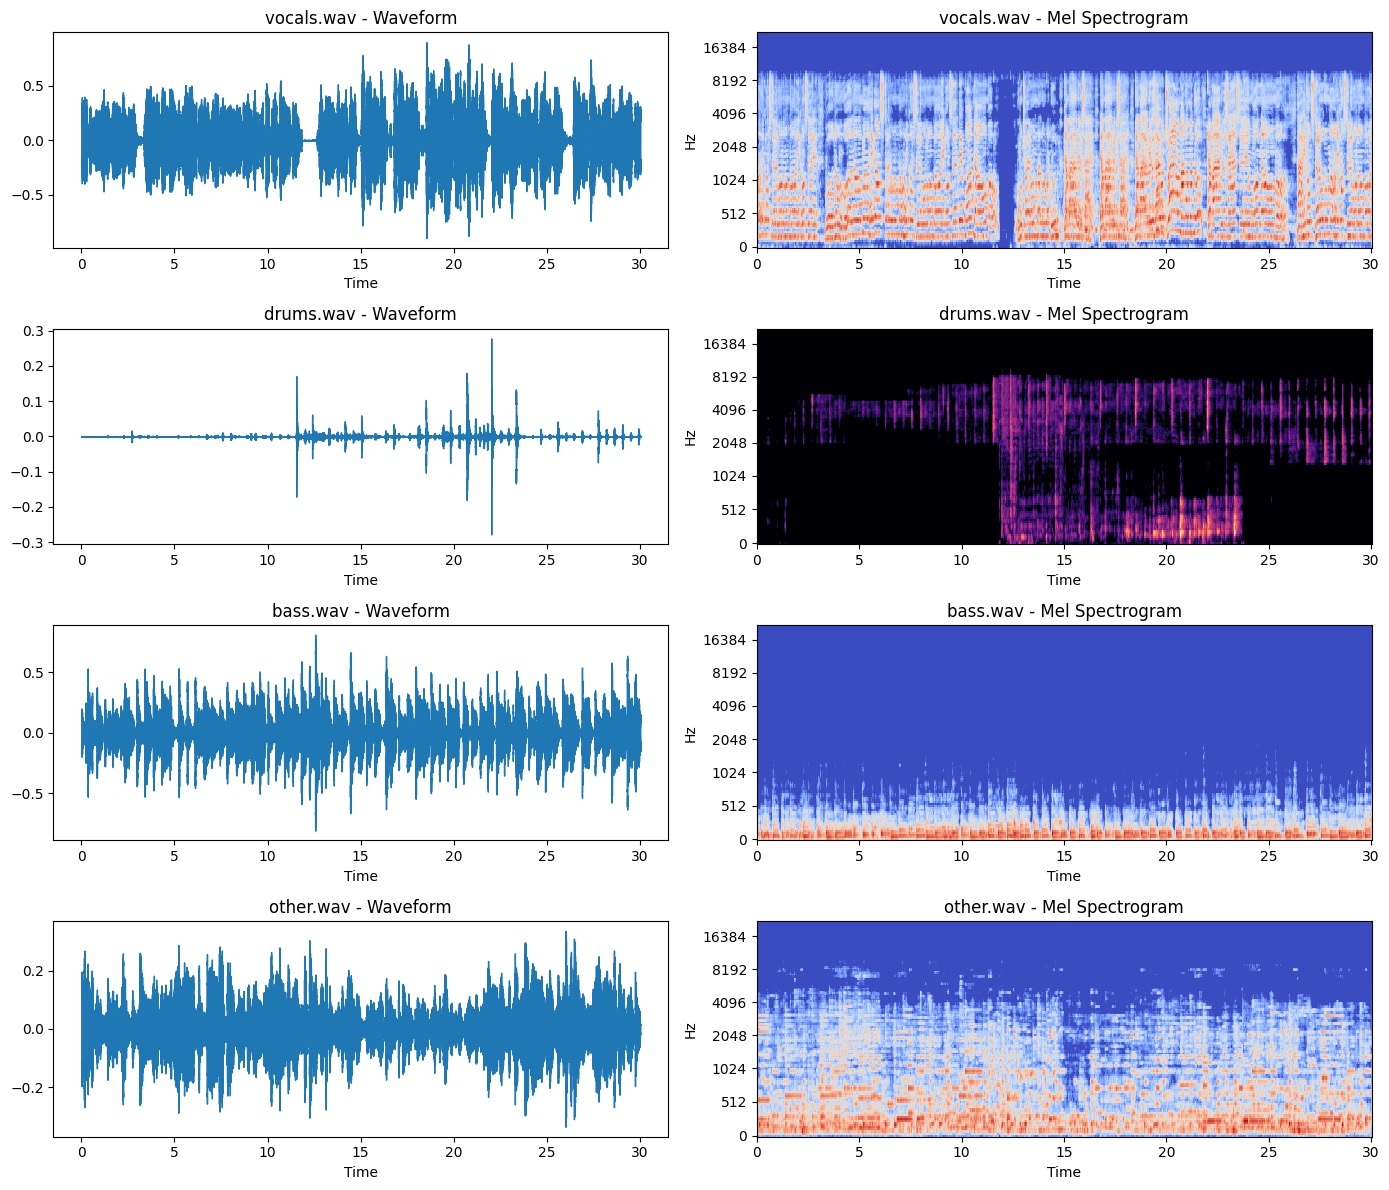

In [5]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt

stems = ["vocals.wav", "drums.wav", "bass.wav", "other.wav"]

sample_folder = os.listdir(os.path.join(TRAIN_DIR, genres[0]))[0]
base_path = os.path.join(TRAIN_DIR, genres[0], sample_folder)

fig, axes = plt.subplots(4, 2, figsize=(14, 12))

for i, stem in enumerate(stems):
    file_path = os.path.join(base_path, stem)
    
    if not os.path.exists(file_path):
        continue
    
    y, sr = librosa.load(file_path, sr=None)
    
    librosa.display.waveshow(y, sr=sr, ax=axes[i, 0])
    axes[i, 0].set_title(f"{stem} - Waveform")
    
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel)
    
    img = librosa.display.specshow(
        mel_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[i, 1]
    )
    axes[i, 1].set_title(f"{stem} - Mel Spectrogram")

plt.tight_layout()
plt.show()

In [6]:
SR = 44100
DURATION = 7
NUM_SAMPLES = SR * DURATION
BATCH_SIZE = 8
EPOCHS = 10
LR = 1e-3

GENRE_TO_IDX = {g:i for i,g in enumerate(genres)}
IDX_TO_GENRE = {i:g for i,g in enumerate(genres)}

NOISE_DIR = os.path.join(BASE_DIR, "ESC-50-master", "audio")

noise_files = []
if os.path.exists(NOISE_DIR):
    noise_files = [os.path.join(NOISE_DIR, f) for f in os.listdir(NOISE_DIR) if f.endswith('.wav')]
print(f"Loaded {len(noise_files)} noise samples.")

Loaded 2000 noise samples.


In [7]:
def load_augmented_audio(sample_path, genre, noise_paths):
    stems = ["vocals.wav", "drums.wav", "bass.wav","other.wav"]  
    audio = np.zeros(NUM_SAMPLES)
    genre_dir = os.path.join(TRAIN_DIR, genre)
    all_genre_songs = os.listdir(genre_dir)
    
    for s in stems:
        if random.random() < 0.5:
            random_song = random.choice(all_genre_songs)
            stem_path = os.path.join(genre_dir, random_song, s)
        else:
            stem_path = os.path.join(sample_path, s)
            
        y, _ = librosa.load(stem_path, sr=SR)
        
        if len(y) > NUM_SAMPLES:
            start = random.randint(0, len(y) - NUM_SAMPLES)
            y = y[start:start+NUM_SAMPLES]
        else:
            y = np.pad(y, (0, NUM_SAMPLES - len(y)))
            
        volume_factor = random.uniform(0.3, 1.5)
        audio += (y * volume_factor)

    max_amp = np.max(np.abs(audio))
    if max_amp > 0:
        audio /= max_amp

    if noise_paths and random.random() < 0.7:
        noise_path = random.choice(noise_paths)
        noise_y, _ = librosa.load(noise_path, sr=SR)
        
        if len(noise_y) > NUM_SAMPLES:
            start = random.randint(0, len(noise_y) - NUM_SAMPLES)
            noise_y = noise_y[start:start+NUM_SAMPLES]
        else:
            noise_y = np.pad(noise_y, (0, NUM_SAMPLES - len(noise_y)))
            
        noise_level = random.uniform(0.05, 0.3) 
        audio += noise_level * noise_y

    return audio

In [8]:
class GenreDataset(Dataset):
    def __init__(self, samples, labels=None, is_test=False):
        self.samples = samples
        self.labels = labels
        self.is_test = is_test

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path = self.samples[idx]

        if self.is_test:
            audio, _ = librosa.load(path, sr=SR)

            crops = []
            step = max(1, (len(audio) - NUM_SAMPLES) // 4)
            positions = [i * step for i in range(5)]

            for p in positions:
                crop = audio[p:p+NUM_SAMPLES]
                if len(crop) < NUM_SAMPLES:
                    crop = np.pad(crop, (0, NUM_SAMPLES - len(crop)))

                mel = librosa.feature.melspectrogram(y=crop, sr=SR, n_mels=128)
                mel = librosa.power_to_db(mel)

                img = np.stack([mel, mel, mel], axis=0)
                img = (img - img.mean()) / (img.std() + 1e-6)
                img = torch.tensor(img, dtype=torch.float32)
                img = torch.nn.functional.interpolate(img.unsqueeze(0), size=(224, 224)).squeeze(0)
                crops.append(img)

            crops = torch.stack(crops)
            return crops

        else:
            genre_idx = self.labels[idx]
            genre_name = IDX_TO_GENRE[genre_idx]
            
            audio = load_augmented_audio(path, genre_name, noise_files)

            mel = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=128)
            mel = librosa.power_to_db(mel)


            if random.random() < 0.7:
                
                num_mel_channels = mel.shape[0]
                f_mask = random.randint(5, 20) 
                f0 = random.randint(0, num_mel_channels - f_mask)
                mel[f0:f0+f_mask, :] = mel.min() 

                num_time_steps = mel.shape[1]
                t_mask = random.randint(10, 40)
                t0 = random.randint(0, num_time_steps - t_mask)
                mel[:, t0:t0+t_mask] = mel.min()

            img = np.stack([mel, mel, mel], axis=0)
            img = (img - img.mean()) / (img.std() + 1e-6)

            img = torch.tensor(img, dtype=torch.float32)
            img = torch.nn.functional.interpolate(img.unsqueeze(0), size=(224, 224)).squeeze(0)

            return img, genre_idx

In [9]:
samples = []
labels = []

for g in genres:
    for s in os.listdir(os.path.join(TRAIN_DIR, g)):
        samples.append(os.path.join(TRAIN_DIR, g, s))
        labels.append(GENRE_TO_IDX[g])

train_s, val_s, train_l, val_l = train_test_split(
    samples, labels, test_size=0.2, stratify=labels, random_state=42
)

train_ds = GenreDataset(train_s, train_l)
val_ds = GenreDataset(val_s, val_l)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

In [10]:
# class TransferNN(nn.Module):
#     def __init__(self, num_classes=10):
#         super().__init__()
#         self.backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
#         num_ftrs = self.backbone.classifier[1].in_features
#         self.backbone.classifier[1] = nn.Sequential(
#             nn.Dropout(p=0.4, inplace=False),
#             nn.Linear(num_ftrs, 512),
#             nn.BatchNorm1d(512),
#             nn.SiLU(),
#             nn.Dropout(p=0.3, inplace=False),
#             nn.Linear(512, num_classes)
#         )

#     def forward(self, x):
#         return self.backbone(x)

# model = TransferNN(num_classes=10).to(device)

In [11]:
class Resnet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.backbone(x)

model = Resnet().to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 149MB/s]


In [12]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [13]:
def train_one_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pred = out.argmax(1)

        correct += (pred == y).sum().item()
        total += y.size(0)

        all_preds.extend(pred.cpu().tolist())
        all_labels.extend(y.cpu().tolist())

    return total_loss/len(loader), correct/total, f1_score(all_labels, all_preds, average="macro")

In [14]:
def validate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item()
            pred = out.argmax(1)

            correct += (pred == y).sum().item()
            total += y.size(0)

            all_preds.extend(pred.cpu().tolist())
            all_labels.extend(y.cpu().tolist())

    return total_loss/len(loader), correct/total, f1_score(all_labels, all_preds, average="macro")

In [15]:
import wandb
import os
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
os.environ["WANDB_API_KEY"] = user_secrets.get_secret("WANDB_API_KEY")

wandb.login()

best_f1 = 0

wandb.init(
    project="DL-GenAI-Final",
    name="Resnet",
    config={"lr": LR, "epochs": EPOCHS, "batch": BATCH_SIZE}
)

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [16]:
for epoch in range(EPOCHS):

    train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader)
    val_loss, val_acc, val_f1 = validate(model, val_loader)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Train F1={train_f1:.4f} | Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}, Val F1={val_f1:.4f}")
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), "model.pth")

    wandb.log({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_f1": train_f1,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1
    })

    scheduler.step()

wandb.finish()

Epoch 1: Train Loss=2.1234, Train Acc=0.2450, Train F1=0.2383 | Val Loss=2.3990, Val Acc=0.2650, Val F1=0.2129
Epoch 2: Train Loss=1.9427, Train Acc=0.3538, Train F1=0.3362 | Val Loss=1.7873, Val Acc=0.3900, Val F1=0.3482
Epoch 3: Train Loss=1.8884, Train Acc=0.3563, Train F1=0.3498 | Val Loss=2.2160, Val Acc=0.2900, Val F1=0.2287
Epoch 4: Train Loss=1.7819, Train Acc=0.4050, Train F1=0.3936 | Val Loss=1.9584, Val Acc=0.3650, Val F1=0.3348
Epoch 5: Train Loss=1.7230, Train Acc=0.4562, Train F1=0.4412 | Val Loss=2.1105, Val Acc=0.3600, Val F1=0.2978
Epoch 6: Train Loss=1.6995, Train Acc=0.4688, Train F1=0.4569 | Val Loss=1.5736, Val Acc=0.4950, Val F1=0.4693
Epoch 7: Train Loss=1.5727, Train Acc=0.5337, Train F1=0.5261 | Val Loss=1.3568, Val Acc=0.6300, Val F1=0.6098
Epoch 8: Train Loss=1.5088, Train Acc=0.5500, Train F1=0.5443 | Val Loss=1.4912, Val Acc=0.5500, Val F1=0.5267
Epoch 9: Train Loss=1.4873, Train Acc=0.5525, Train F1=0.5461 | Val Loss=1.1702, Val Acc=0.7250, Val F1=0.7092


wandb: updating run metadata


Epoch 10: Train Loss=1.4104, Train Acc=0.6050, Train F1=0.5991 | Val Loss=1.1588, Val Acc=0.7400, Val F1=0.7339


wandb: uploading history steps 9-9, summary, console lines 9-9
wandb: 
wandb: Run history:
wandb:      epoch ▁▂▃▃▄▅▆▆▇█
wandb:  train_acc ▁▃▃▄▅▅▇▇▇█
wandb:   train_f1 ▁▃▃▄▅▅▇▇▇█
wandb: train_loss █▆▆▅▄▄▃▂▂▁
wandb:    val_acc ▁▃▁▂▂▄▆▅██
wandb:     val_f1 ▁▃▁▃▂▄▆▅██
wandb:   val_loss █▅▇▆▆▃▂▃▁▁
wandb: 
wandb: Run summary:
wandb:      epoch 9
wandb:  train_acc 0.605
wandb:   train_f1 0.59915
wandb: train_loss 1.41043
wandb:    val_acc 0.74
wandb:     val_f1 0.7339
wandb:   val_loss 1.15877
wandb: 
wandb: 🚀 View run Resnet at: https://wandb.ai/23f2002371-indian-institute-of-technology-madras/DL-GenAI-Final/runs/4o5vuqxr
wandb: ⭐️ View project at: https://wandb.ai/23f2002371-indian-institute-of-technology-madras/DL-GenAI-Final
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260401_145020-4o5vuqxr/logs


In [17]:
test_df = pd.read_csv(TEST_CSV)
test_files = [os.path.join(TEST_DIR, os.path.basename(f)) for f in test_df["filename"]]
test_ds = GenreDataset(test_files, is_test=True)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)

model.load_state_dict(torch.load("model.pth", map_location=device))
model.eval()

preds = []
with torch.no_grad():
    for x in tqdm(test_loader):
        b, n, c, h, w = x.shape
        
        x = x.view(-1, c, h, w).to(device) 
        
        out = model(x)
        
        probs = torch.nn.functional.softmax(out, dim=1)
        
        probs = probs.view(b, n, -1).mean(dim=1) 
        
        preds.extend(probs.argmax(1).cpu().numpy())

labels = [IDX_TO_GENRE[p] for p in preds]

submission = pd.DataFrame({
    "id": test_df["id"],
    "genre": labels
})
submission.to_csv("submission.csv", index=False)
submission.head()

100%|██████████| 378/378 [08:55<00:00,  1.42s/it]


,id,genre
0,1,pop
1,2,jazz
2,3,pop
3,4,metal
4,5,country
